## **Carga inicial de librerías**

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score, precision_score, recall_score, \
    f1_score
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

## **Cargar el dataset**

In [2]:
df = pd.read_csv("../spotify_songs.csv")
df.head()

,track_id,track_name,track_artist,track_popularity,track_album_id,track_album_name,track_album_release_date,playlist_name,playlist_id,playlist_genre,...,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_ms
0,6f807x0ima9a1j3VPbc7VN,I Don't Care (with Justin Bieber) - Loud Luxur...,Ed Sheeran,66,2oCs0DGTsRO98Gh5ZSl2Cx,I Don't Care (with Justin Bieber) [Loud Luxury...,2019-06-14,Pop Remix,37i9dQZF1DXcZDD7cfEKhW,pop,...,6,-2.634,1,0.0583,0.1020,0.000000,0.0653,0.518,122.036,194754
1,0r7CVbZTWZgbTCYdfa2P31,Memories - Dillon Francis Remix,Maroon 5,67,63rPSO264uRjW1X5E6cWv6,Memories (Dillon Francis Remix),2019-12-13,Pop Remix,37i9dQZF1DXcZDD7cfEKhW,pop,...,11,-4.969,1,0.0373,0.0724,0.004210,0.3570,0.693,99.972,162600
2,1z1Hg7Vb0AhHDiEmnDE79l,All the Time - Don Diablo Remix,Zara Larsson,70,1HoSmj2eLcsrR0vE9gThr4,All the Time (Don Diablo Remix),2019-07-05,Pop Remix,37i9dQZF1DXcZDD7cfEKhW,pop,...,1,-3.432,0,0.0742,0.0794,0.000023,0.1100,0.613,124.008,176616
3,75FpbthrwQmzHlBJLuGdC7,Call You Mine - Keanu Silva Remix,The Chainsmokers,60,1nqYsOef1yKKuGOVchbsk6,Call You Mine - The Remixes,2019-07-19,Pop Remix,37i9dQZF1DXcZDD7cfEKhW,pop,...,7,-3.778,1,0.1020,0.0287,0.000009,0.2040,0.277,121.956,169093
4,1e8PAfcKUYoKkxPhrHqw4x,Someone You Loved - Future Humans Remix,Lewis Capaldi,69,7m7vv9wlQ4i0LFuJiE2zsQ,Someone You Loved (Future Humans Remix),2019-03-05,Pop Remix,37i9dQZF1DXcZDD7cfEKhW,pop,...,1,-4.672,1,0.0359,0.0803,0.000000,0.0833,0.725,123.976,189052


In [3]:
df.shape
df.info()

df.isnull().sum()
df.duplicated().sum()
df["playlist_genre"].value_counts()

<class 'pandas.DataFrame'>
RangeIndex: 32833 entries, 0 to 32832
Data columns (total 23 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   track_id                  32833 non-null  str    
 1   track_name                32828 non-null  str    
 2   track_artist              32828 non-null  str    
 3   track_popularity          32833 non-null  int64  
 4   track_album_id            32833 non-null  str    
 5   track_album_name          32828 non-null  str    
 6   track_album_release_date  32833 non-null  str    
 7   playlist_name             32833 non-null  str    
 8   playlist_id               32833 non-null  str    
 9   playlist_genre            32833 non-null  str    
 10  playlist_subgenre         32833 non-null  str    
 11  danceability              32833 non-null  float64
 12  energy                    32833 non-null  float64
 13  key                       32833 non-null  int64  
 14  loudness         

playlist_genre
edm      6043
rap      5746
pop      5507
r&b      5431
latin    5155
rock     4951
Name: count, dtype: int64

## **Data cleaning**

In [4]:
df_model = df.drop(columns=[
    "playlist_name",
    "playlist_id",
    "track_id",
    "track_name",
    "track_artist",
    "track_album_id",
    "track_album_name",
    "track_album_release_date",
    "playlist_subgenre"
])

df_model.head()

,track_popularity,playlist_genre,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_ms
0,66,pop,0.748,0.916,6,-2.634,1,0.0583,0.1020,0.000000,0.0653,0.518,122.036,194754
1,67,pop,0.726,0.815,11,-4.969,1,0.0373,0.0724,0.004210,0.3570,0.693,99.972,162600
2,70,pop,0.675,0.931,1,-3.432,0,0.0742,0.0794,0.000023,0.1100,0.613,124.008,176616
3,60,pop,0.718,0.930,7,-3.778,1,0.1020,0.0287,0.000009,0.2040,0.277,121.956,169093
4,69,pop,0.650,0.833,1,-4.672,1,0.0359,0.0803,0.000000,0.0833,0.725,123.976,189052


***Eliminando identificadores.***

***Quitando texto que no aporta al modelo***

***Evitando que playlist_subgenre sesgue el target principal .***

## **Descripción del dataset**

In [5]:
df_model.describe().T

,count,mean,std,min,25%,50%,75%,max
track_popularity,32833.0,42.477081,24.984074,0.000000,24.0000,45.000000,62.00000,100.000
danceability,32833.0,0.654850,0.145085,0.000000,0.5630,0.672000,0.76100,0.983
energy,32833.0,0.698619,0.180910,0.000175,0.5810,0.721000,0.84000,1.000
key,32833.0,5.374471,3.611657,0.000000,2.0000,6.000000,9.00000,11.000
loudness,32833.0,-6.719499,2.988436,-46.448000,-8.1710,-6.166000,-4.64500,1.275
mode,32833.0,0.565711,0.495671,0.000000,0.0000,1.000000,1.00000,1.000
speechiness,32833.0,0.107068,0.101314,0.000000,0.0410,0.062500,0.13200,0.918
acousticness,32833.0,0.175334,0.219633,0.000000,0.0151,0.080400,0.25500,0.994
instrumentalness,32833.0,0.084747,0.224230,0.000000,0.0000,0.000016,0.00483,0.994
liveness,32833.0,0.190176,0.154317,0.000000,0.0927,0.127000,0.24800,0.996


### **Distribución de la clase objetivo**

In [6]:
df["playlist_genre"].value_counts(normalize=True)

playlist_genre
edm      0.184053
rap      0.175007
pop      0.167728
r&b      0.165413
latin    0.157007
rock     0.150793
Name: proportion, dtype: float64

C:\Users\Sebastian-EDU\AppData\Local\Temp\ipykernel_9696\3748724455.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=genre_counts.index, y=genre_counts.values, ax=ax[0], palette="Set1")


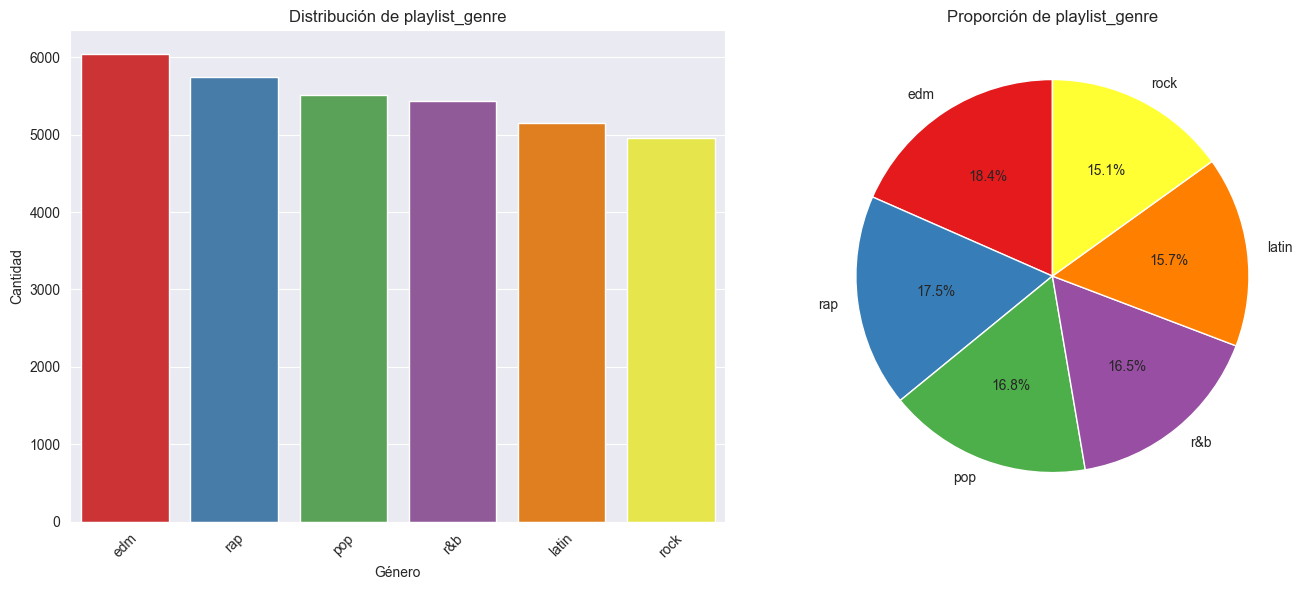

In [7]:
genre_counts = df["playlist_genre"].value_counts()
fig, ax = plt.subplots(1, 2, figsize=(14, 6))

# Gráfico de barras
sns.barplot(x=genre_counts.index, y=genre_counts.values, ax=ax[0], palette="Set1")
ax[0].set_title("Distribución de playlist_genre")
ax[0].set_xlabel("Género")
ax[0].set_ylabel("Cantidad")
ax[0].tick_params(axis="x", rotation=45)

# Gráfico de pastel
ax[1].pie(
    genre_counts.values,
    labels=genre_counts.index,
    autopct="%1.1f%%",
    startangle=90,
    colors=sns.color_palette("Set1", len(genre_counts))
)
ax[1].set_title("Proporción de playlist_genre")

plt.tight_layout()
plt.show()

## **Análisis de correlación**

In [8]:
num_cols = df_model.select_dtypes(include=np.number).columns
corr = df_model[num_cols].corr()

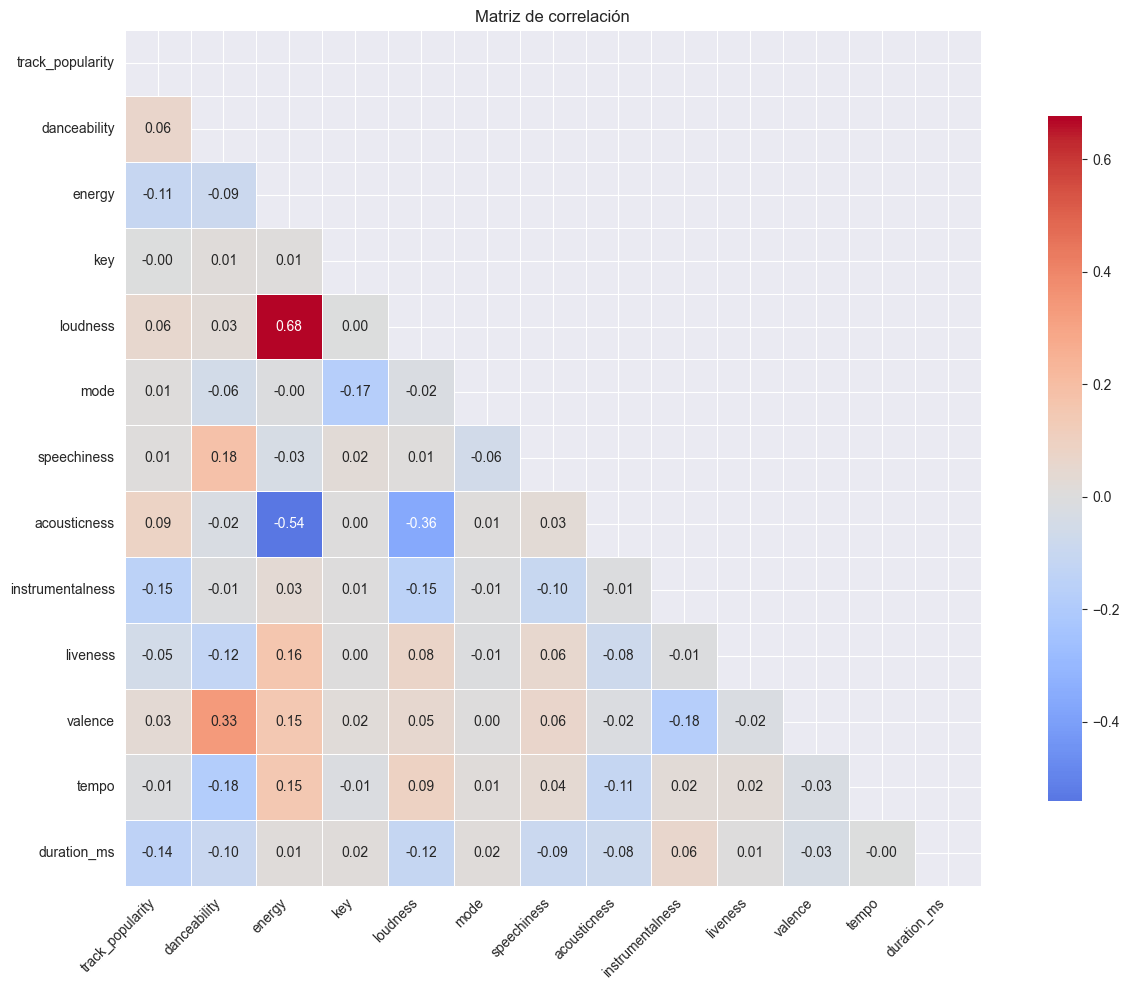

In [9]:
plt.figure(figsize=(14, 10))

mask = np.triu(np.ones_like(corr, dtype=bool))

sns.heatmap(
    corr,
    mask=mask,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    linewidths=0.5,
    linecolor="white",
    square=True,
    cbar_kws={"shrink": 0.8}
)

plt.title("Matriz de correlación")
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

## **Definir X e y**

In [10]:
X = df_model.drop(columns=["playlist_genre"])
y = df_model["playlist_genre"]

In [11]:


cols_modelo = [
    "track_popularity", "danceability", "energy", "key", "loudness",
    "mode", "speechiness", "acousticness", "instrumentalness",
    "liveness", "valence", "tempo", "duration_ms", "playlist_genre"
]

dfmodel = df[cols_modelo].copy()

dfmodel = dfmodel.drop_duplicates()
dfmodel = dfmodel.dropna()

X = dfmodel.drop(columns=["playlist_genre"])
y = dfmodel["playlist_genre"]

## **Train, validation y test**

In [12]:
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=42, stratify=y_temp
)

## **Ingeniería de características**
 - No se creó una transformación compleja.

- Se trabajó con variables originales.

- Se descartaron columnas de identificación y texto.

- Solo se mantuvieron variables útiles para clasificación.

- Se normalizaron variables numéricas en el pipeline.



## **Preparación del mejor modelo**

El mejor modelo fue Gradient Boosting con estos hiperparámetros:

- n_estimators = 200

- learning_rate = 0.1

- max_depth = 4

- min_samples_split = 2

- random_state = 42

In [13]:
gb_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("model", GradientBoostingClassifier(
        n_estimators=200,
        learning_rate=0.1,
        max_depth=4,
        min_samples_split=2,
        random_state=42
    ))
])

In [14]:
print(X.select_dtypes(exclude=["number"]).columns)

Index([], dtype='str')


## **Entrenar**

In [15]:
gb_pipeline.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('scaler', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
,"loss loss: {'log_loss', 'exponential'}, default='log_loss'The loss function to be optimized. 'log_loss' refers to binomial andmultinomial deviance, the same as used in logistic regression.It is a good choice for classification with probabilistic outputs.For loss 'exponential', gradient boosting recovers the AdaBoost algorithm.",'log_loss'
,"learning_rate learning_rate: float, default=0.1Learning rate shrinks the contribution of each tree by `learning_rate`.There is a trade-off between learning_rate and n_estimators.Values must be in the range `[0.0, inf)`.For an example of the effects of this parameter and its interaction with``subsample``, see:ref:`sphx_glr_auto_examples_ensemble_plot_gradient_boosting_regularization.py`.",0.1
,"n_estimators n_estimators: int, default=100The number of boosting stages to perform. Gradient boostingis fairly robust to over-fitting so a large number usuallyresults in better performance.Values must be in the range `[1, inf)`.",200
,"subsample subsample: float, default=1.0The fraction of samples to be used for fitting the individual baselearners. If smaller than 1.0 this results in Stochastic GradientBoosting. `subsample` interacts with the parameter `n_estimators`.Choosing `subsample < 1.0` leads to a reduction of varianceand an increase in bias.Values must be in the range `(0.0, 1.0]`.",1.0


In [16]:
from pathlib import Path
import joblib

project_root = Path.cwd().parent
models_dir = project_root / "models"
models_dir.mkdir(exist_ok=True)

joblib.dump(gb_pipeline, models_dir / "gb_pipeline.pkl")

['C:\\Users\\Sebastian-EDU\\Documents\\GitHub\\EvolutionaryComputation\\SpotifyGenre\\models\\gb_pipeline.pkl']

In [17]:
model_test = joblib.load(project_root / "models" / "gb_pipeline.pkl")

## **Evaluar el modelo**

### **Predicción**

In [18]:
y_val_pred = gb_pipeline.predict(X_val)
y_test_pred = gb_pipeline.predict(X_test)

  Métrica  Valor
 Accuracy 0.5504
Precision 0.5486
   Recall 0.5504
       F1 0.5479


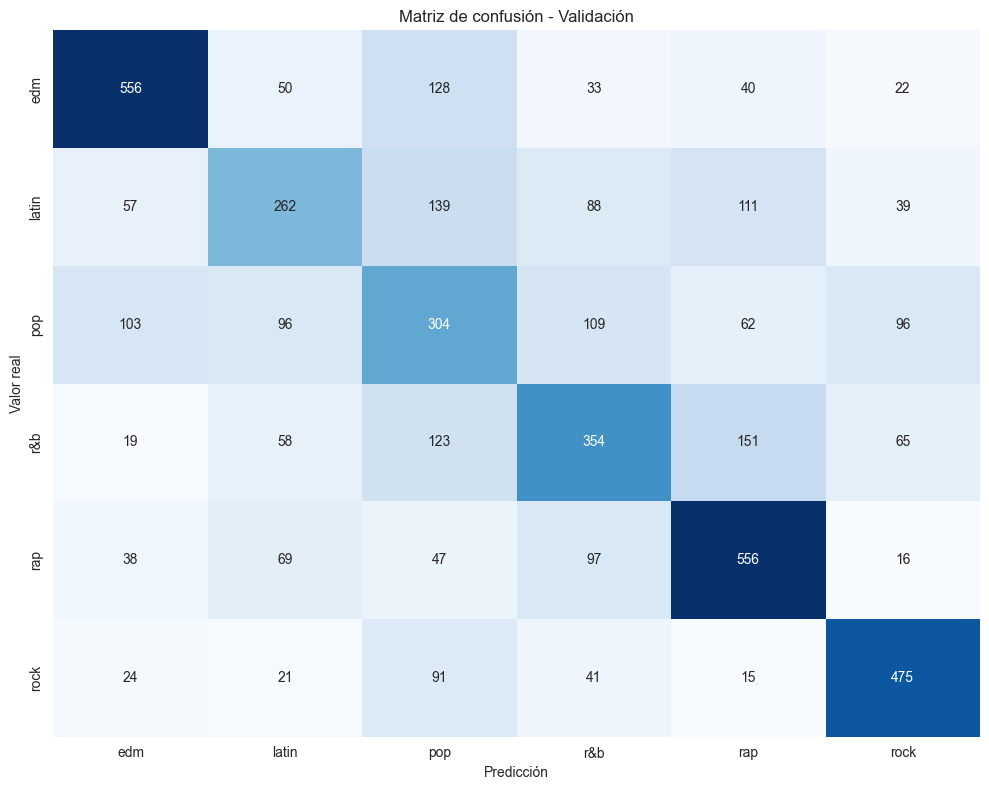


Reporte de clasificación:
              precision    recall  f1-score   support

         edm       0.70      0.67      0.68       829
       latin       0.47      0.38      0.42       696
         pop       0.37      0.39      0.38       770
         r&b       0.49      0.46      0.47       770
         rap       0.59      0.68      0.63       823
        rock       0.67      0.71      0.69       667

    accuracy                           0.55      4555
   macro avg       0.55      0.55      0.55      4555
weighted avg       0.55      0.55      0.55      4555



In [19]:
metricas = pd.DataFrame({
    "Métrica": ["Accuracy", "Precision", "Recall", "F1"],
    "Valor": [
        accuracy_score(y_val, y_val_pred),
        precision_score(y_val, y_val_pred, average="weighted", zero_division=0),
        recall_score(y_val, y_val_pred, average="weighted", zero_division=0),
        f1_score(y_val, y_val_pred, average="weighted", zero_division=0),
    ]
})

print(metricas.to_string(index=False, float_format=lambda x: f"{x:.4f}"))

labels = sorted(pd.Series(y_val).unique())
cm = confusion_matrix(y_val, y_val_pred, labels=labels)

plt.figure(figsize=(10, 8))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=labels,
    yticklabels=labels,
    cbar=False
)
plt.title("Matriz de confusión - Validación")
plt.xlabel("Predicción")
plt.ylabel("Valor real")
plt.tight_layout()
plt.show()

print("\nReporte de clasificación:")
print(classification_report(y_val, y_val_pred, zero_division=0))

TEST
  Métrica  Valor
 Accuracy 0.5344
Precision 0.5326
   Recall 0.5344
       F1 0.5323


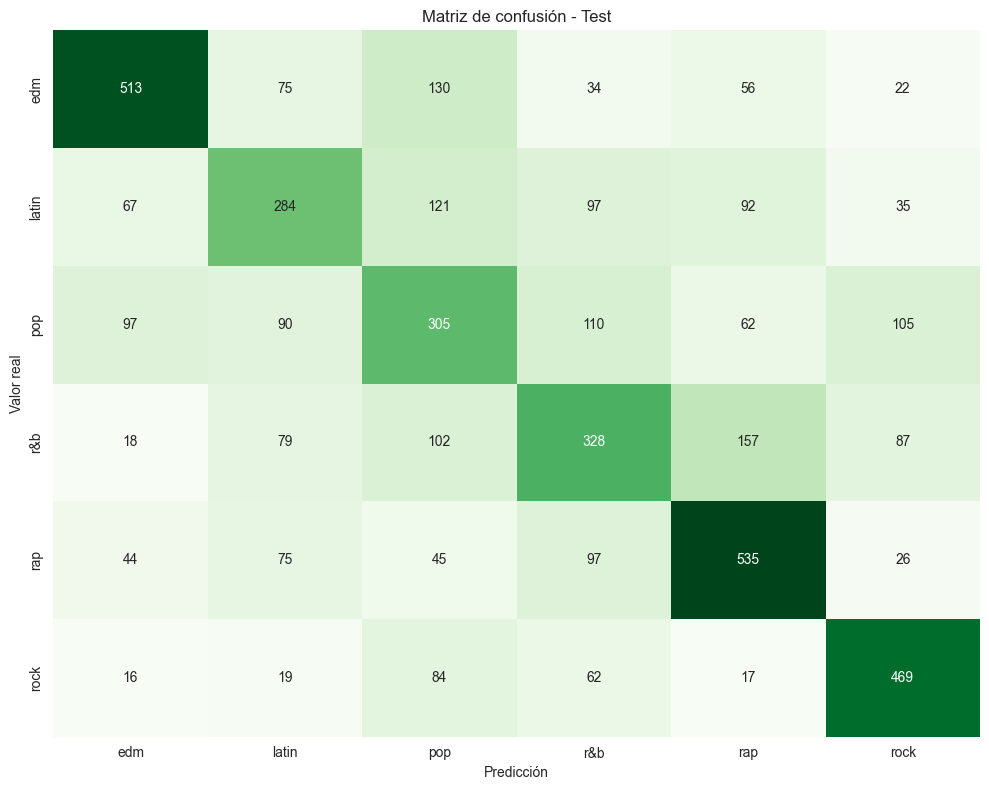


Reporte de clasificación - Test:
              precision    recall  f1-score   support

         edm       0.68      0.62      0.65       830
       latin       0.46      0.41      0.43       696
         pop       0.39      0.40      0.39       769
         r&b       0.45      0.43      0.44       771
         rap       0.58      0.65      0.61       822
        rock       0.63      0.70      0.66       667

    accuracy                           0.53      4555
   macro avg       0.53      0.53      0.53      4555
weighted avg       0.53      0.53      0.53      4555



In [20]:
metricas_test = pd.DataFrame({
    "Métrica": ["Accuracy", "Precision", "Recall", "F1"],
    "Valor": [
        accuracy_score(y_test, y_test_pred),
        precision_score(y_test, y_test_pred, average="weighted", zero_division=0),
        recall_score(y_test, y_test_pred, average="weighted", zero_division=0),
        f1_score(y_test, y_test_pred, average="weighted", zero_division=0),
    ]
})

print("TEST")
print(metricas_test.to_string(index=False, float_format=lambda x: f"{x:.4f}"))

labels_test = sorted(pd.Series(y_test).unique())
cm_test = confusion_matrix(y_test, y_test_pred, labels=labels_test)

plt.figure(figsize=(10, 8))
sns.heatmap(
    cm_test,
    annot=True,
    fmt="d",
    cmap="Greens",
    xticklabels=labels_test,
    yticklabels=labels_test,
    cbar=False
)
plt.title("Matriz de confusión - Test")
plt.xlabel("Predicción")
plt.ylabel("Valor real")
plt.tight_layout()
plt.show()

print("\nReporte de clasificación - Test:")
print(classification_report(y_test, y_test_pred, zero_division=0))

### **Hiperparámetros**

In [21]:
rf_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("model", RandomForestClassifier(
        n_estimators=200,
        max_depth=10,
        random_state=42
    ))
])

In [22]:
rf_pipeline.fit(X_train, y_train)
rf_pred = rf_pipeline.predict(X_test)

print("RF accuracy:", accuracy_score(y_test, rf_pred))
print("RF precision:", precision_score(y_test, rf_pred, average="weighted"))
print("RF recall:", recall_score(y_test, rf_pred, average="weighted"))
print("RF f1:", f1_score(y_test, rf_pred, average="weighted"))

RF accuracy: 0.5106476399560922
RF precision: 0.5016308737925156
RF recall: 0.5106476399560922
RF f1: 0.5024286983639716


## *Ensamble*

In [23]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import VotingClassifier, RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, \
    classification_report

lr = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(max_iter=3000, solver="lbfgs"))
])

rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    random_state=42
)

dt = DecisionTreeClassifier(random_state=42)

ensamble = VotingClassifier(
    estimators=[
        ("lr", lr),
        ("rf", rf),
        ("dt", dt)
    ],
    voting="hard"
)

ensamble.fit(X_train, y_train)
y_ens = ensamble.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_ens))
print("Precision:", precision_score(y_test, y_ens, average="weighted", zero_division=0))
print("Recall:", recall_score(y_test, y_ens, average="weighted", zero_division=0))
print("F1:", f1_score(y_test, y_ens, average="weighted", zero_division=0))
print(confusion_matrix(y_test, y_ens))
print(classification_report(y_test, y_ens, zero_division=0))

Accuracy: 0.4823271130625686
Precision: 0.47022750515668055
Recall: 0.4823271130625686
F1: 0.4730267096773766
[[544  60 115  33  53  25]
 [125 254 101  77 107  32]
 [188 105 196  93  69 118]
 [ 49  96  91 278 176  81]
 [ 86  92  34  90 493  27]
 [ 58  34  73  60  10 432]]
              precision    recall  f1-score   support

         edm       0.52      0.66      0.58       830
       latin       0.40      0.36      0.38       696
         pop       0.32      0.25      0.28       769
         r&b       0.44      0.36      0.40       771
         rap       0.54      0.60      0.57       822
        rock       0.60      0.65      0.63       667

    accuracy                           0.48      4555
   macro avg       0.47      0.48      0.47      4555
weighted avg       0.47      0.48      0.47      4555



## **PyCaret**
PyCaret es una librería de machine learning de bajo código diseñada para acelerar el flujo de trabajo de clasificación, regresión y otras tareas de analítica predictiva. Su instalación oficial se recomienda en entornos de 64 bits y la documentación señala compatibilidad probada con Python 3.9, 3.10 y 3.11; además, su API incluye funciones como setup() y compare_models() para automatizar preprocesamiento, entrenamiento y comparación de modelos.

Durante la ejecución se identificó una limitación de compatibilidad con el entorno de trabajo. La documentación oficial indica que PyCaret está probado y soportado en Python 3.9, 3.10 y 3.11, mientras que el entorno utilizado en este proyecto opera con Python 3.12, lo que generó errores de importación e impidió su uso final. Por esta razón, la comparación y selección del modelo se realizó con scikit-learn, manteniendo un flujo reproducible y compatible con el resto del proyecto.



In [24]:
from pyngrok import ngrok

ngrok.set_auth_token("3DQnUZPGAHExxsmj8fcyobaVCPx_RJHxZwgPZVHSUfGqDeeU")
public_url = ngrok.connect(8000)
print(public_url)

NgrokTunnel: "https://surrender-enrage-cascade.ngrok-free.dev" -> "http://localhost:8000"                                                                                                               


## Conclusiones
En este proyecto se desarrolló un sistema de clasificación para predecir el género musical de una canción a partir de variables acústicas y de popularidad extraídas del dataset de Spotify. El proceso inició con la limpieza de datos, la eliminación de columnas de identificación y texto no útil para el modelado, y la revisión de estadísticas descriptivas para entender la distribución de las variables numéricas. Esto permitió construir una base de datos más adecuada para el entrenamiento de modelos supervisados.

El análisis exploratorio mostró que las clases objetivo presentaban cierta desproporción, aunque no extrema, lo cual fue importante tener en cuenta al evaluar el desempeño de los modelos. También se identificó que varias variables tenían comportamientos diferenciados entre géneros, por lo que el problema sí era abordable mediante aprendizaje automático. En este sentido, el trabajo confirmó que las características musicales pueden aportar información útil para distinguir géneros, aunque la separación no es perfecta debido a la superposición natural entre ellos.

Durante la fase de modelado se evaluaron diferentes algoritmos de clasificación con métricas como accuracy, precision, recall y F1-score. Los resultados evidenciaron que el rendimiento global se ubicó en un rango moderado, alrededor de 0.43 en accuracy y F1 weighted en los experimentos observados, lo cual indica que el modelo sí aprende patrones, pero todavía tiene limitaciones para separar correctamente todas las clases. Esto sugiere que el problema es multiclase y complejo, y que las variables disponibles no capturan por completo la variabilidad musical de cada género.

El ensamble tipo voting también fue probado como estrategia adicional. Sin embargo, su desempeño no superó de forma clara al mejor modelo individual, y además uno de sus componentes, la regresión logística, presentó advertencias de convergencia. Por esta razón, el ensamble no resultó ser la mejor opción final para el proyecto. En términos prácticos, esto muestra que combinar modelos no siempre garantiza una mejora, especialmente cuando algunos estimadores requieren mayor ajuste o cuando las variables no están completamente estandarizadas.

La implementación mediante Pipeline permitió estructurar el flujo de trabajo de forma ordenada y reproducible, integrando preprocesamiento y modelo en un solo objeto. Esta decisión facilita tanto la evaluación como el despliegue posterior, porque reduce errores de consistencia entre entrenamiento y predicción. Además, la integración con FastAPI permitió transformar el modelo en un servicio consumible mediante una API, lo cual conecta el trabajo académico con una aplicación más cercana a un entorno real de producción.

PyCaret se investigó como herramienta de AutoML para acelerar la comparación de modelos y simplificar la experimentación. No obstante, su uso final no fue posible debido a incompatibilidades de versión con el entorno de trabajo, ya que la librería soporta oficialmente Python 3.9, 3.10 y 3.11, mientras que el entorno estaba en Python 3.12. Por ello, la comparación final se mantuvo dentro del ecosistema de scikit-learn, lo que permitió conservar estabilidad, control y compatibilidad con el resto del proyecto.